In [1]:
import sys
from pathlib import Path

# notebooks → deep
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from utils import load_run_data

PROJECT_ROOT: /usr/project/xtmp/ds541/td-avar-explore/deep


In [2]:
import pandas as pd
import numpy as np

# Configuration
envs = ('Asterix-MinAtar', 'Breakout-MinAtar', 'Freeway-MinAtar', 'SpaceInvaders-MinAtar', 'SparseMountainCar-v0', 'DeepSea-bsuite')

results = []
suffix = 'cov_lstd'
for env in envs:
    # for suffix in ('cov_lstd'):
    for rew in ('phi', 'next_phi'):
        for reset_trace in ('true', 'false'):
            try:
                # Load the data
                path = f'{suffix}/2026-01-19/rew_{rew}_RESET_TRACE_{reset_trace}'
                config, metrics = load_run_data(path, env)
            
                curve = metrics['returned_episode_returns'].mean(0)
                final_score = np.mean(curve[-100:]) 
                
                # Append to list
                results.append({
                    'Environment': env,
                    'Setting': f"{suffix} (R={rew}, Tr={reset_trace})", # Combine settings into one column header
                    'Score': final_score
                })
                    
            except Exception as e:
                print(e)
                continue

# 1. Create Long-form DataFrame
df = pd.DataFrame(results)

final_table = df.pivot(index='Environment', columns='Setting', values='Score')

# Optional: formatting to look nice
pd.options.display.float_format = '{:,.2f}'.format
final_table

# If you want to save it:
# final_table.to_csv("results_table.csv")

Setting,"cov_lstd (R=next_phi, Tr=false)","cov_lstd (R=next_phi, Tr=true)","cov_lstd (R=phi, Tr=false)","cov_lstd (R=phi, Tr=true)"
Environment,,,,
Asterix-MinAtar,39.259804,45.899746,55.53624,45.348423
Breakout-MinAtar,73.85963,57.09389,69.12499,62.830532
DeepSea-bsuite,0.24401592,-0.005035864,0.24419665,-0.004780649
Freeway-MinAtar,64.463394,65.148735,64.65325,64.45239
SpaceInvaders-MinAtar,165.12595,165.6511,164.40157,166.62648
SparseMountainCar-v0,0.8665982,0.8665119,0.8668318,0.86712015


In [4]:

results = []
for env in envs:
    for suffix in ('cov_lstd', 'cov_lstd_one_critic'):
        for EFFECTIVE_VISITS_TO_REMAIN_OPT in ('10', '100'):
            for fixed_alpha in ('', '_fixed_alpha'):
                try:
                    # Load the data
                    path = f'{suffix}/2026-01-19/OPTIMISTIC_{EFFECTIVE_VISITS_TO_REMAIN_OPT}{fixed_alpha}'
                    config, metrics = load_run_data(path, env)
                    
                    curve = metrics['returned_episode_returns'].mean(0)
                    final_score = np.mean(curve[-250:]) 
                    
                    # Append to list
                    results.append({
                        'Environment': env,
                        'Setting': f"{suffix} opt={EFFECTIVE_VISITS_TO_REMAIN_OPT} {fixed_alpha}", # Combine settings into one column header
                        'Score': final_score
                    })
                        
                except Exception as e:
                    print(e)
                    continue

# 1. Create Long-form DataFrame
df = pd.DataFrame(results)

final_table = df.pivot(index='Environment', columns='Setting', values='Score')

# Optional: formatting to look nice
pd.options.display.float_format = '{:,.2f}'.format
final_table

# If you want to save it:
# final_table.to_csv("results_table.csv")

[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_10_fixed_alpha/SparseMountainCar-v0/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_100_fixed_alpha/SparseMountainCar-v0/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd_one_critic/2026-01-19/OPTIMISTIC_10_fixed_alpha/SparseMountainCar-v0/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd_one_critic/2026-01-19/OPTIMISTIC_100_fixed_alpha/SparseMountainCar-v0/config.json'


Setting,cov_lstd opt=10,cov_lstd opt=10 _fixed_alpha,cov_lstd opt=100,cov_lstd opt=100 _fixed_alpha,cov_lstd_one_critic opt=10,cov_lstd_one_critic opt=10 _fixed_alpha,cov_lstd_one_critic opt=100,cov_lstd_one_critic opt=100 _fixed_alpha
Environment,,,,,,,,
Asterix-MinAtar,46.79201,58.302532,26.581701,48.207382,42.70424,42.70424,54.19308,29.58215
Breakout-MinAtar,82.592155,89.66512,81.91194,83.93248,81.15547,81.15547,69.24726,90.89754
DeepSea-bsuite,0.64612174,0.64858866,0.35421017,0.37821013,0.5596579,0.19945388,0.551509,0.48610085
Freeway-MinAtar,65.38343,48.6556,64.77267,48.29819,65.37738,65.37738,65.28351,65.044716
SpaceInvaders-MinAtar,166.28807,163.33495,166.74437,161.86545,164.6088,164.6088,166.48048,166.93954
SparseMountainCar-v0,0.8677747,NaN,0.8668318,NaN,0.8683114,NaN,0.8684061,NaN


### Mixed results above but generally N_eff = 10 is perfectly adaquate. Fixing alpha is good for Asterix, Breakout, Deepsea, bad for Freeway and space invaders. 

In [ ]:
results = []
for env in envs:
    for suffix in ('cov_lstd', 'cov_lstd_one_critic'):
        for opt in ('true', 'false'):
            for per_state_opt in ('true', 'false'):
                try:
                    # Load the data
                    path = f'{suffix}/2026-01-19/OPTIMISTIC_{opt}_PER_STATE_OPT_{per_state_opt}'
                    config, metrics = load_run_data(path, env)
                    
                    curve = metrics['returned_episode_returns'].mean(0)
                    final_score = np.mean(curve[-250:]) 
                    
                    # Append to list
                    results.append({
                        'Environment': env,
                        'Setting': f"{suffix} opt={opt} per_state_opt={per_state_opt}", # Combine settings into one column header
                        'Score': final_score
                    })
                        
                except Exception as e:
                    print(e)
                    continue

# 1. Create Long-form DataFrame
df = pd.DataFrame(results)

final_table = df.pivot(index='Environment', columns='Setting', values='Score')

# Optional: formatting to look nice
pd.options.display.float_format = '{:,.2f}'.format
final_table

# If you want to save it:
# final_table.to_csv("results_table.csv")

[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Asterix-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd_one_critic/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Asterix-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Breakout-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd_one_critic/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Breakout-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Freeway-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd_one_critic/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Freeway-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/SpaceInvaders-MinAtar/config.json'
[Errno 2] No such fil

Setting,cov_lstd opt=false per_state_opt=false,cov_lstd opt=true per_state_opt=false,cov_lstd opt=true per_state_opt=true,cov_lstd_one_critic opt=false per_state_opt=false,cov_lstd_one_critic opt=true per_state_opt=false,cov_lstd_one_critic opt=true per_state_opt=true
Environment,,,,,,
Asterix-MinAtar,47.679127,53.70794,33.800774,42.70424,37.11072,37.11072
Breakout-MinAtar,82.592155,68.401115,86.475006,81.15547,86.54447,86.54447
DeepSea-bsuite,0.64612174,0.10834767,0.17341293,0.34054312,0.31726667,0.2572984
Freeway-MinAtar,64.791176,64.40123,64.72595,65.37738,64.57121,64.57121
SpaceInvaders-MinAtar,166.93248,166.26535,165.72507,164.6088,164.48009,164.48009
SparseMountainCar-v0,0.8677747,0.8668318,0.8674569,0.8683114,0.8684061,0.8684061


In [10]:
results = []
for env in envs:
    for suffix in ('cov_lstd', 'cov_lstd_one_critic'):
        for opt in ('true', 'false'):
            for per_state_opt in ('true', 'false'):
                try:
                    # Load the data
                    path = f'{suffix}/2026-01-19/OPTIMISTIC_{opt}_PER_STATE_OPT_{per_state_opt}'
                    config, metrics = load_run_data(path, env)
                    
                    curve = metrics['returned_episode_returns'].mean(0)
                    final_score = np.mean(curve[-250:]) 
                    
                    # Append to list
                    results.append({
                        'Environment': env,
                        'Setting': f"{suffix} opt={opt} per_state_opt={per_state_opt}", # Combine settings into one column header
                        'Score': final_score
                    })
                        
                except Exception as e:
                    print(e)
                    continue

# 1. Create Long-form DataFrame
df = pd.DataFrame(results)

final_table = df.pivot(index='Environment', columns='Setting', values='Score')

# Optional: formatting to look nice
pd.options.display.float_format = '{:,.2f}'.format
final_table

# If you want to save it:
# final_table.to_csv("results_table.csv")

[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Asterix-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd_one_critic/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Asterix-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Breakout-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd_one_critic/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Breakout-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Freeway-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd_one_critic/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/Freeway-MinAtar/config.json'
[Errno 2] No such file or directory: '../results/cov_lstd/2026-01-19/OPTIMISTIC_false_PER_STATE_OPT_true/SpaceInvaders-MinAtar/config.json'
[Errno 2] No such fil

Setting,cov_lstd opt=false per_state_opt=false,cov_lstd opt=true per_state_opt=false,cov_lstd opt=true per_state_opt=true,cov_lstd_one_critic opt=false per_state_opt=false,cov_lstd_one_critic opt=true per_state_opt=false,cov_lstd_one_critic opt=true per_state_opt=true
Environment,,,,,,
Asterix-MinAtar,47.679127,53.70794,33.800774,57.33008,32.03739,32.03739
Breakout-MinAtar,82.592155,68.401115,86.475006,92.52532,73.38187,73.38187
DeepSea-bsuite,0.64612174,0.10834767,0.17341293,0.20120089,0.28627795,0.28627795
Freeway-MinAtar,64.791176,64.40123,64.72595,32.439896,64.547745,64.54189
SpaceInvaders-MinAtar,166.93248,166.26535,165.72507,166.70842,166.25598,166.25598
SparseMountainCar-v0,0.8677747,0.8668318,0.8674569,0.878338,0.8787989,0.8787989


In [7]:
import pandas as pd
import numpy as np


results = []
for env in envs:
    for suffix in ('cov_lstd', 'cov_lstd_one_critic'):
        for clip in ('true', 'false'):
            try:
                # Load the data
                path = f'{suffix}/2026-01-19/test_two_critics_clip_ri_{clip}'
                config, metrics = load_run_data(path, env)
                
                curve = metrics['returned_episode_returns'].mean(0)
                final_score = np.mean(curve[-250:]) 
                
                # Append to list
                results.append({
                    'Environment': env,
                    'Setting': f"{suffix} clip={clip}", # Combine settings into one column header
                    'Score': final_score
                })
                    
            except Exception as e:
                print(e)
                continue

# 1. Create Long-form DataFrame
df = pd.DataFrame(results)

final_table = df.pivot(index='Environment', columns='Setting', values='Score')

# Optional: formatting to look nice
pd.options.display.float_format = '{:,.2f}'.format
final_table

# If you want to save it:
# final_table.to_csv("results_table.csv")

Setting,cov_lstd clip=false,cov_lstd clip=true,cov_lstd_one_critic clip=false,cov_lstd_one_critic clip=true
Environment,,,,
Asterix-MinAtar,53.70794,53.70794,32.28524,32.28524
Breakout-MinAtar,67.955635,68.401115,87.926895,87.926895
DeepSea-bsuite,0.08548271,0.14597291,0.3180088,0.25298643
Freeway-MinAtar,64.40123,64.40123,64.35296,64.35296
SpaceInvaders-MinAtar,163.93806,163.93806,168.64404,168.64404
SparseMountainCar-v0,0.8668318,0.8668318,0.87858003,0.87858003


In [4]:
import pandas as pd
import numpy as np

results = []
suffix = 'cov_lstd'
for env in envs:
    # for suffix in ('cov_lstd'):
    for decay in ('true', 'false'):

            try:
                # Load the data
                path = f'{suffix}/2026-01-19/DECAY_BETA_{decay}'
                config, metrics = load_run_data(path, env)
                
                # GET THE SCORE: 
                # Since a table needs a single number, we usually take the mean 
                # of the final 10% of timesteps (final performance).
                # Adjust [-10:] to whatever window you prefer.
                curve = metrics['returned_episode_returns'].mean(0)
                final_score = np.mean(curve[-100:]) 
                
                # Append to list
                results.append({
                    'Environment': env,
                    'Setting': f"{suffix} (Decay={decay})", # Combine settings into one column header
                    'Score': final_score
                })
                    
            except Exception as e:
                print(e)
                # Add NaN if data is missing so the table stays aligned
                # results.append({
                #     'Environment': env,
                #     'Setting': f"{suffix} (Lin={linear}, Episodic = {episodic}))",
                #     'Score': float('nan')
                # })
                continue

# 1. Create Long-form DataFrame
df = pd.DataFrame(results)
df
# 2. Pivot to make "Each Env as a Row"
# Index = Environment
# Columns = The Settings
# Values = The Result (Score)
final_table = df.pivot(index='Environment', columns='Setting', values='Score')

# Optional: formatting to look nice
pd.options.display.float_format = '{:,.2f}'.format
final_table

# If you want to save it:
# final_table.to_csv("results_table.csv")

Setting,cov_lstd (Decay=false),cov_lstd (Decay=true)
Environment,,
Asterix-MinAtar,55.53624,46.55258
Breakout-MinAtar,69.12499,79.252426
DeepSea-bsuite,-0.0012441176,0.24373324
Freeway-MinAtar,64.65325,65.23514
SpaceInvaders-MinAtar,164.40157,163.97224
SparseMountainCar-v0,0.8668318,0.8668318


In [5]:
results = []

for env in envs:
    for suffix in ('cov_net', 'cov_lstd_one_critic'):
        for rew in ('phi', 'next_phi'):
            for decay in ('true', 'false'):
                try:
                    # Load the data
                    path = f'{suffix}/2026-01-19/rew_{rew}_decay_{decay}'
                    config, metrics = load_run_data(path, env)
                    
                    # GET THE SCORE: 
                    # Since a table needs a single number, we usually take the mean 
                    # of the final 10% of timesteps (final performance).
                    # Adjust [-10:] to whatever window you prefer.
                    curve = metrics['returned_episode_returns'].mean(0)
                    final_score = np.mean(curve[-100:]) 
                    
                    # Append to list
                    results.append({
                        'Environment': env,
                        'Setting': f"{suffix} (R={rew}, D={decay})", # Combine settings into one column header
                        'Score': final_score
                    })
                        
                except Exception as e:
                    continue

# 1. Create Long-form DataFrame
df = pd.DataFrame(results)

# 2. Pivot to make "Each Env as a Row"
# Index = Environment
# Columns = The Settings
# Values = The Result (Score)
final_table = df.pivot(index='Environment', columns='Setting', values='Score')

# Optional: formatting to look nice
pd.options.display.float_format = '{:,.2f}'.format
# print(final_table)
final_table

# If you want to save it:
# final_table.to_csv("results_table.csv")

Setting,"cov_lstd_one_critic (R=next_phi, D=false)","cov_lstd_one_critic (R=next_phi, D=true)","cov_lstd_one_critic (R=phi, D=false)","cov_lstd_one_critic (R=phi, D=true)","cov_net (R=next_phi, D=false)","cov_net (R=next_phi, D=true)","cov_net (R=phi, D=false)","cov_net (R=phi, D=true)"
Environment,,,,,,,,
Asterix-MinAtar,31.627188,23.783112,23.781015,20.253466,24.30832,25.514688,28.566525,23.941034
Breakout-MinAtar,53.938614,63.910477,53.723503,69.604195,59.747948,36.40639,44.930653,61.48408
DeepSea-bsuite,-0.0041996413,0.2461182,0.095856495,0.7419905,0.74133086,0.24725464,0.74129134,0.9889393
Freeway-MinAtar,62.449753,62.50429,62.480633,62.569893,63.23013,62.96293,63.69162,63.114937
SpaceInvaders-MinAtar,169.56696,168.80295,166.67566,169.8153,168.61336,168.26418,171.36859,170.61092
SparseMountainCar-v0,0.88369644,0.882501,0.8835007,0.8827978,0.8259782,0.8246039,0.82106805,0.82268447


In [6]:
results = []

for env in envs:
    for suffix in ('cov_net', 'cov_lstd'):
        for episodic in ('true', 'false'):
            for linear in ('true', 'false'):
                try:
                    # Load the data
                    path = f'{suffix}/E_{episodic}_L_{linear}'
                    config, metrics = load_run_data(path, env)
                    
                    # GET THE SCORE: 
                    # Since a table needs a single number, we usually take the mean 
                    # of the final 10% of timesteps (final performance).
                    # Adjust [-10:] to whatever window you prefer.
                    curve = metrics['returned_episode_returns'].mean(0)
                    final_score = np.mean(curve[-25:]) 
                    
                    # Append to list
                    results.append({
                        'Environment': env,
                        'Setting': f"{suffix} (Lin={linear}, Episodic = {episodic})", # Combine settings into one column header
                        'Score': final_score
                    })
                        
                except Exception as e:
                    continue

# 1. Create Long-form DataFrame
df = pd.DataFrame(results)

# 2. Pivot to make "Each Env as a Row"
# Index = Environment
# Columns = The Settings
# Values = The Result (Score)
final_table = df.pivot(index='Environment', columns='Setting', values='Score')

# Optional: formatting to look nice
pd.options.display.float_format = '{:,.2f}'.format
# print(final_table)
final_table

# If you want to save it:
# final_table.to_csv("results_table.csv")

Setting,"cov_lstd (Lin=false, Episodic = false)","cov_lstd (Lin=false, Episodic = true)","cov_lstd (Lin=true, Episodic = false)","cov_lstd (Lin=true, Episodic = true)","cov_net (Lin=true, Episodic = false)","cov_net (Lin=true, Episodic = true)"
Environment,,,,,,
Asterix-MinAtar,36.39361,39.814495,25.461283,34.36289,43.53871,49.23945
Breakout-MinAtar,37.08099,91.56895,26.414425,81.409065,86.17956,83.30766
DeepSea-bsuite,0.9846304,-0.0060058855,0.74086934,-0.0054305503,0.98999995,0.7619186
Freeway-MinAtar,66.00348,65.62615,65.88227,65.59875,65.53372,65.364296
SpaceInvaders-MinAtar,169.22928,165.90388,168.85153,171.47374,167.87396,166.96695
SparseMountainCar-v0,0.9999609,0.9999609,1.0,1.0,0.94481444,0.9551953


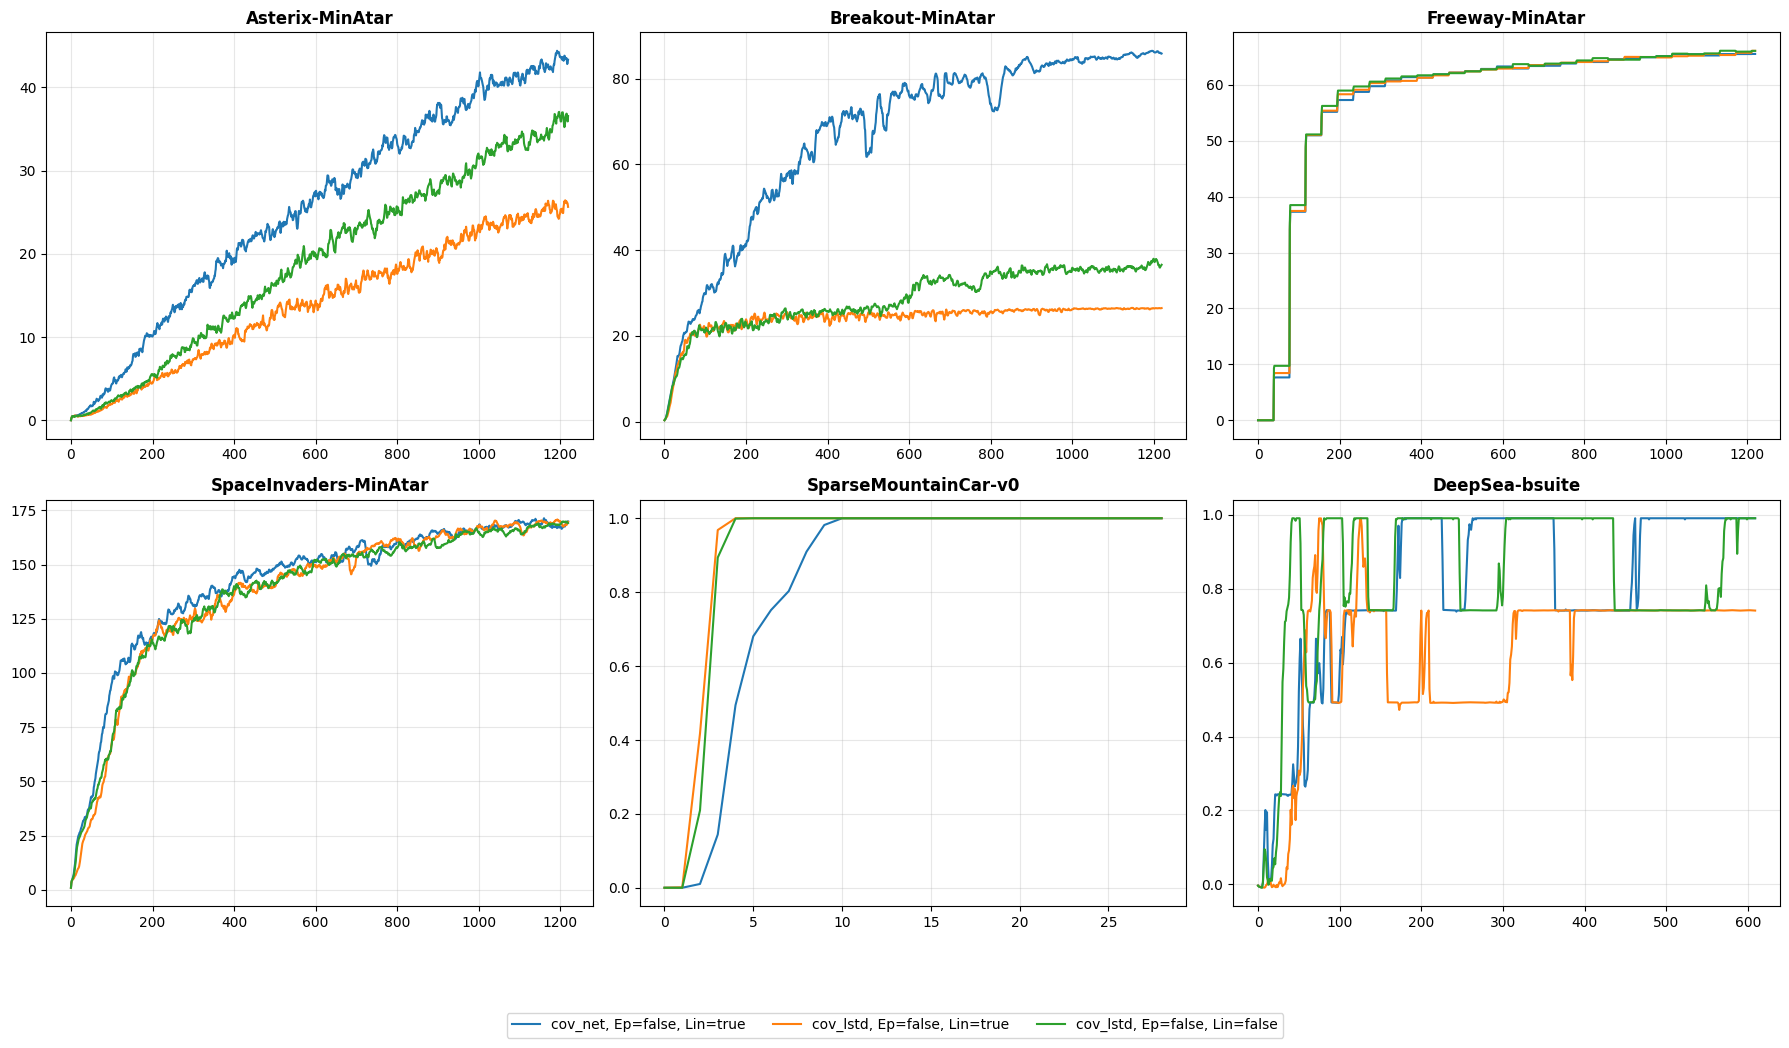

In [7]:
import matplotlib.pyplot as plt
import itertools
# 1. Better Sizing: 2 rows x 3 columns fits 5 envs perfectly with 1 empty spot
# Increased figsize to make individual plots larger
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten() 

# Track handles and labels for the global legend
handles, labels = [], []

for i, (env, ax) in enumerate(zip(envs, axes_flat)):
    for suffix in ('cov_net', 'cov_lstd'):
        for linear in ('true', 'false'):
            try:
                # Construct label string
                label_str = f'{suffix}, Ep={episodic}, Lin={linear}'
                
                config, metrics = load_run_data(f'{suffix}/E_{episodic}_L_{linear}', env)
                
                # Plot the data
                line, = ax.plot(metrics['returned_episode_returns'].mean(0), label=label_str)
                
                # Only collect legend info from the very first subplot to avoid duplicates
                if i == 0:
                    handles.append(line)
                    labels.append(label_str)
                    
            except Exception as e:
                # Optional: print(f"Missing data for {env}: {e}")
                continue

    # Subplot formatting
    ax.set_title(env, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# 2. Hide any unused subplots (in this case, the 6th spot)
for j in range(len(envs), len(axes_flat)):
    axes_flat[j].axis('off')

# 3. Create a Single Global Legend
# bbox_to_anchor places it at the bottom center, ncol spreads it horizontally
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=10)

# Adjust layout to make room for the legend at the bottom
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()

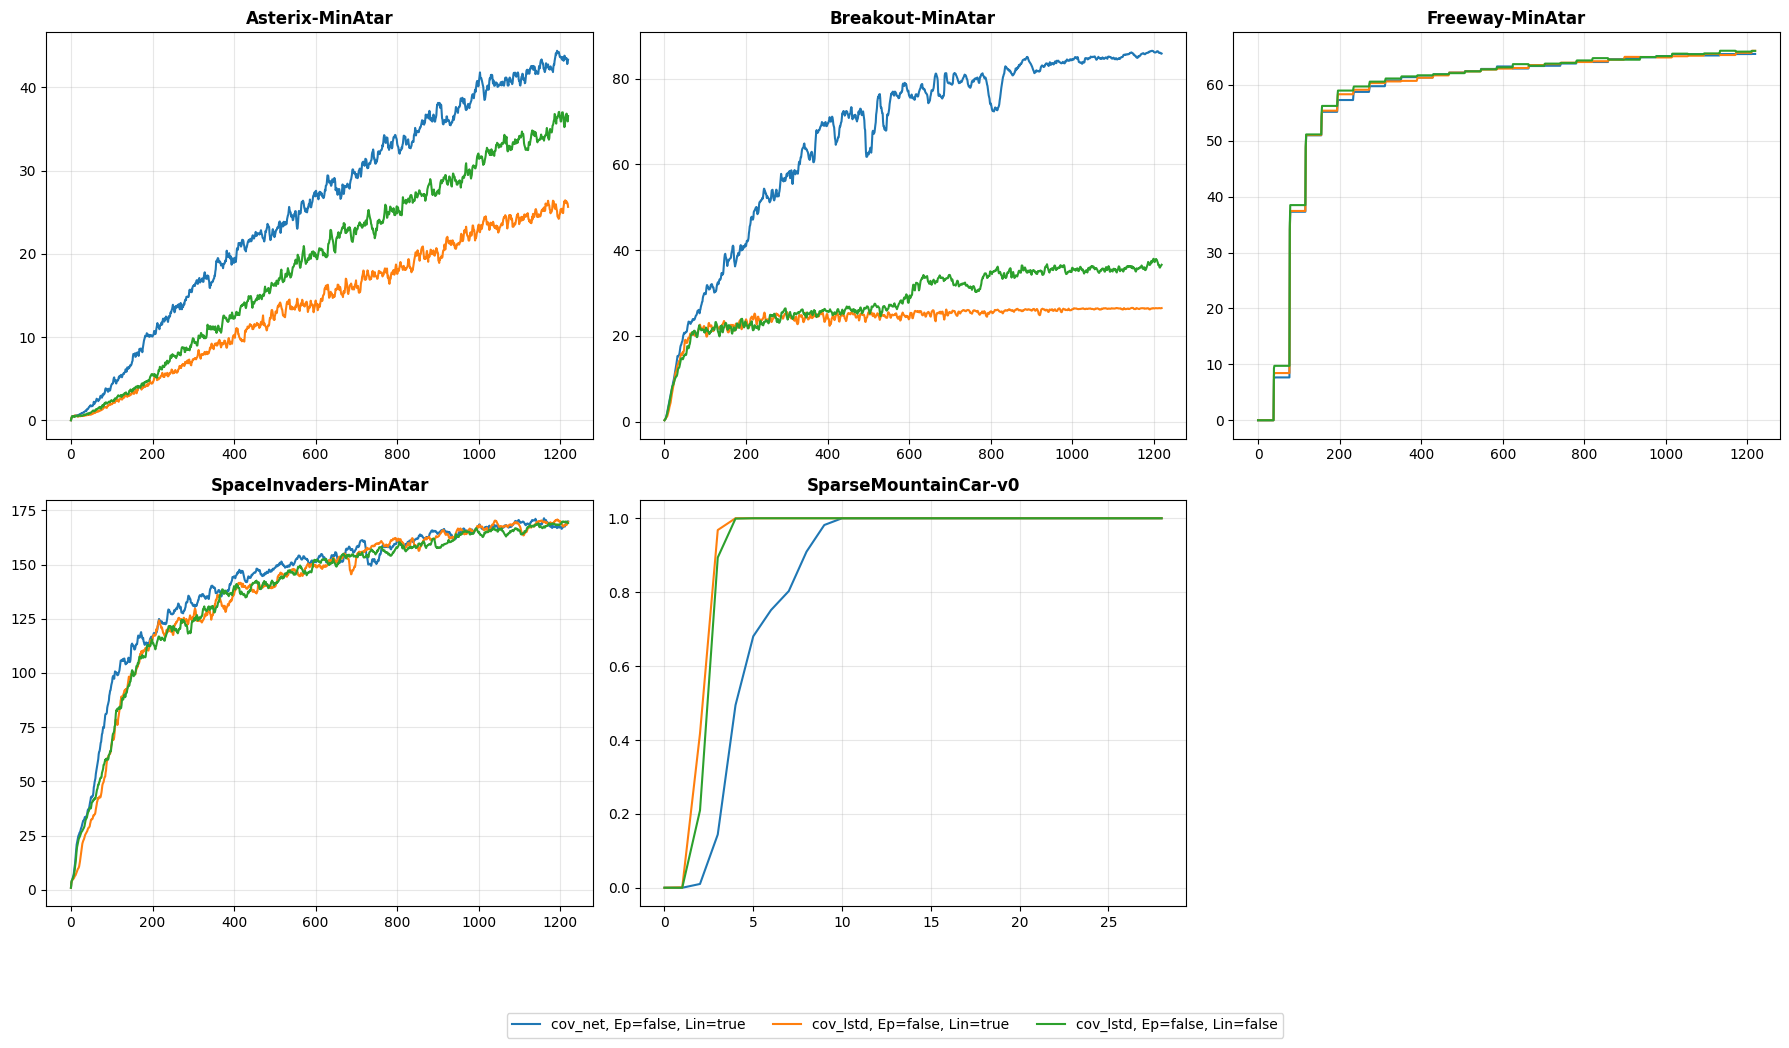

In [8]:
import matplotlib.pyplot as plt
import itertools

episodic = 'false'
envs = ('Asterix-MinAtar', 'Breakout-MinAtar', 'Freeway-MinAtar', 'SpaceInvaders-MinAtar', 'SparseMountainCar-v0')

# 1. Better Sizing: 2 rows x 3 columns fits 5 envs perfectly with 1 empty spot
# Increased figsize to make individual plots larger
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten() 

# Track handles and labels for the global legend
handles, labels = [], []

for i, (env, ax) in enumerate(zip(envs, axes_flat)):
    for suffix in ('cov_net', 'cov_lstd'):
        for linear in ('true', 'false'):
            try:
                # Construct label string
                label_str = f'{suffix}, Ep={episodic}, Lin={linear}'
                
                config, metrics = load_run_data(f'{suffix}/E_{episodic}_L_{linear}', env)
                
                # Plot the data
                line, = ax.plot(metrics['returned_episode_returns'].mean(0), label=label_str)
                
                # Only collect legend info from the very first subplot to avoid duplicates
                if i == 0:
                    handles.append(line)
                    labels.append(label_str)
                    
            except Exception as e:
                # Optional: print(f"Missing data for {env}: {e}")
                continue

    # Subplot formatting
    ax.set_title(env, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# 2. Hide any unused subplots (in this case, the 6th spot)
for j in range(len(envs), len(axes_flat)):
    axes_flat[j].axis('off')

# 3. Create a Single Global Legend
# bbox_to_anchor places it at the bottom center, ncol spreads it horizontally
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=10)

# Adjust layout to make room for the legend at the bottom
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()